# Streamflow Prediction from Time-Lag Embeddings

This notebook demonstrates a fundamental pattern in Earth science machine learning: predicting a quantity at time $t$ from a **time-lag embedding** of past observations. We use daily meteorological data (precipitation $P$ and temperature $T$) from the Leaf River basin to predict streamflow $Q$.

## The time-lag embedding

Streamflow at time $t$ depends not just on today's precipitation, but on the accumulated rainfall and temperature history over the past days to weeks (infiltration, snowmelt, baseflow). We construct a feature vector:

$$
\mathbf{x}(t) = \Big[P(t), P(t-1), \ldots, P(t-L_P), \; T(t), T(t-1), \ldots, T(t-L_T)\Big]
$$

and train a network $f_{\theta}$ to predict:

$$
\hat{Q}(t) = f_{\theta}(\mathbf{x}(t))
$$

This is a **supervised regression** problem with temporal structure. The key challenges are:

1. **Lag window selection** — how many past days $L_P$, $L_T$ to include?
2. **Temporal train/val split** — must predict the future, not interpolate the past
3. **Input normalization** — precipitation and temperature have very different scales

We use a simple **multilayer perceptron (MLP)** as the function approximator. Later notebooks will replace this with recurrent networks (LSTMs) or physics-informed architectures.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

rng = np.random.default_rng(42)
torch.manual_seed(42)

## 1. Load and Explore the Data

The Leaf River basin is a tributary of the Mississippi River. The dataset contains daily observations of precipitation (mm/day), temperature (°C), and streamflow (mm/day).

In [2]:
# Load data
data = pd.read_csv('../../data/LeafRiverDaily.csv')

# Extract variables
precip = data['Precipitation'].values
temp = data['Temperature'].values
streamflow = data['Streamflow'].values

N = len(precip)

print(f"Dataset: {N} daily observations")
print(f"Date range: {N} days ({N/365.25:.1f} years)\n")
print(f"Precipitation — mean: {precip.mean():.2f} mm/day, max: {precip.max():.1f} mm/day")
print(f"Temperature   — mean: {temp.mean():.2f} °C, range: [{temp.min():.1f}, {temp.max():.1f}] °C")
print(f"Streamflow    — mean: {streamflow.mean():.2f} mm/day, max: {streamflow.max():.1f} mm/day")

Dataset: 10960 daily observations
Date range: 10960 days (30.0 years)

Precipitation — mean: 3.87 mm/day, max: 221.5 mm/day
Temperature   — mean: 2.91 °C, range: [0.0, 8.5] °C
Streamflow    — mean: 1.34 mm/day, max: 64.0 mm/day


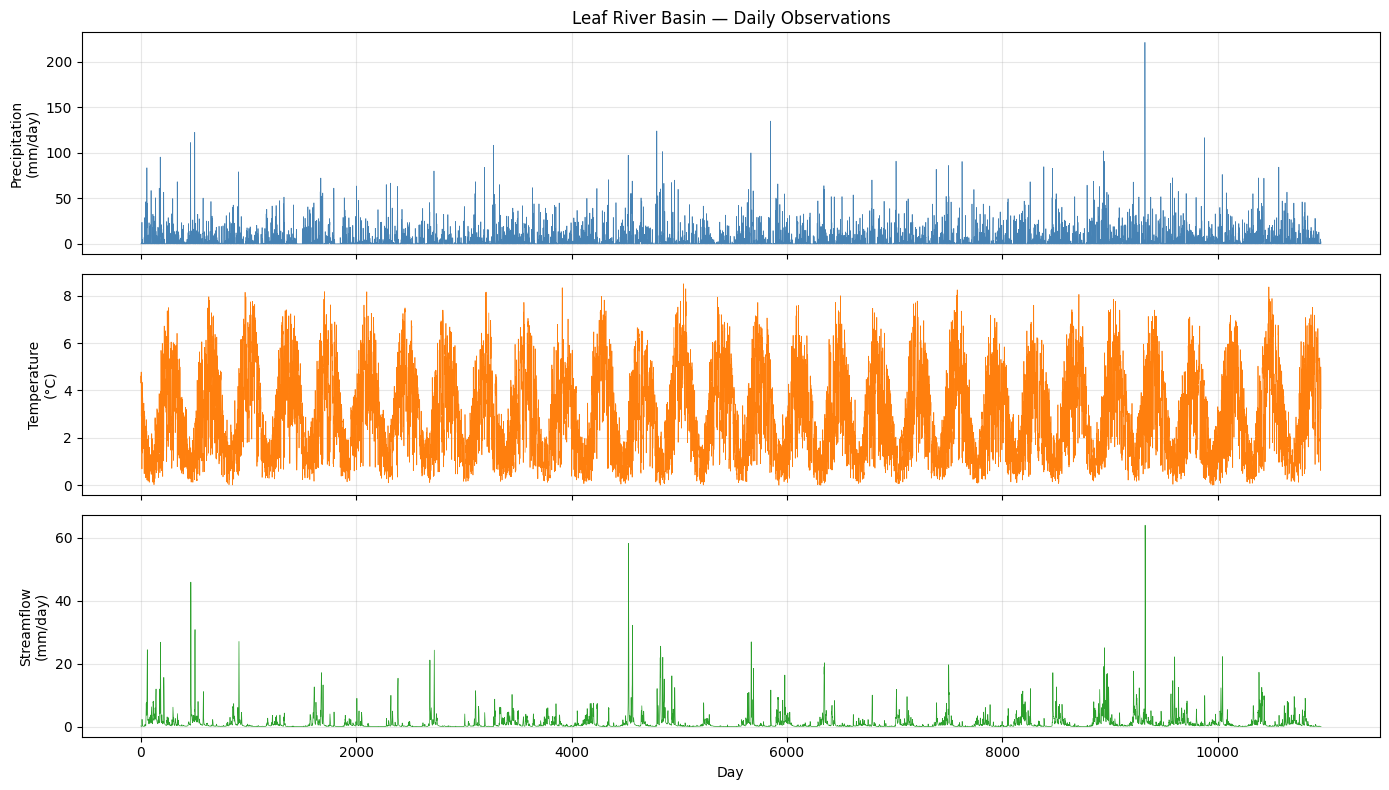

In [3]:
# Visualize time series
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

time_days = np.arange(N)

axes[0].plot(time_days, precip, linewidth=0.5, color='steelblue')
axes[0].set_ylabel('Precipitation\n(mm/day)')
axes[0].set_title('Leaf River Basin — Daily Observations')
axes[0].grid(alpha=0.3)

axes[1].plot(time_days, temp, linewidth=0.5, color='C1')
axes[1].set_ylabel('Temperature\n(°C)')
axes[1].grid(alpha=0.3)

axes[2].plot(time_days, streamflow, linewidth=0.5, color='C2')
axes[2].set_ylabel('Streamflow\n(mm/day)')
axes[2].set_xlabel('Day')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Autocorrelation of Streamflow')

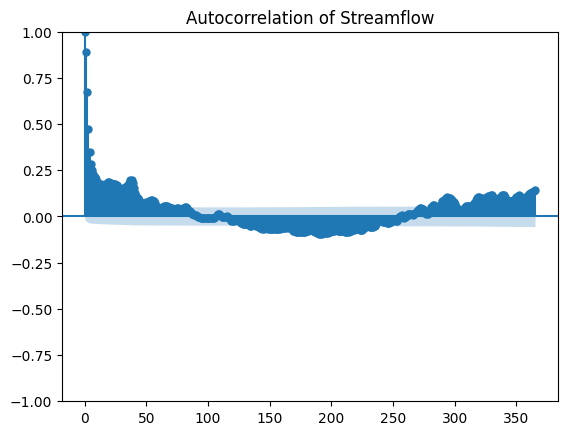

In [26]:
# Plot autocorelation of streamflow
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(streamflow, lags=365)
plt.title('Autocorrelation of Streamflow')

(array([6.048e+03, 5.000e+00, 6.000e+00, 2.500e+01, 4.000e+00, 2.800e+01,
        2.000e+00, 7.000e+00, 4.000e+00, 5.000e+00, 8.000e+00, 9.000e+00,
        7.000e+00, 1.300e+01, 8.000e+00, 9.000e+00, 8.000e+00, 5.000e+00,
        1.600e+01, 1.000e+01, 1.900e+01, 1.400e+01, 2.300e+01, 4.000e+01,
        3.900e+01, 4.400e+01, 4.200e+01, 3.400e+01, 6.100e+01, 7.200e+01,
        6.700e+01, 8.300e+01, 1.130e+02, 1.060e+02, 1.200e+02, 1.600e+02,
        1.880e+02, 1.950e+02, 1.890e+02, 2.660e+02, 2.810e+02, 3.670e+02,
        4.240e+02, 4.560e+02, 4.180e+02, 4.160e+02, 3.060e+02, 1.500e+02,
        3.600e+01, 4.000e+00]),
 array([-11.59951414, -11.29156454, -10.98361493, -10.67566533,
        -10.36771573, -10.05976612,  -9.75181652,  -9.44386691,
         -9.13591731,  -8.8279677 ,  -8.5200181 ,  -8.21206849,
         -7.90411889,  -7.59616928,  -7.28821968,  -6.98027007,
         -6.67232047,  -6.36437086,  -6.05642126,  -5.74847166,
         -5.44052205,  -5.13257245,  -4.82462284,  -4.51

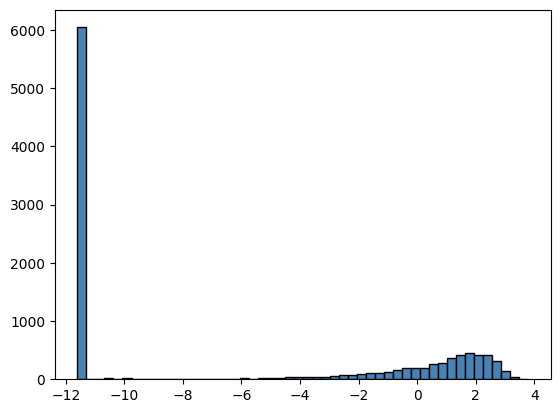

In [14]:
# Import box-cox transformation for better visualization
from scipy.stats import boxcox
v, _ = boxcox(precip+1e-3)
plt.hist(v, bins=50, color='steelblue', edgecolor='k')

Precipitation is highly intermittent (many zero days, occasional large events). Temperature shows strong seasonal variation. Streamflow responds to precipitation events with a lag and has a smoother temporal autocorrelation structure.

## 2. Construct Time-Lag Embeddings

We create a dataset where each sample is:

$$
\text{Input:} \quad \mathbf{x}(t) = [P(t), P(t-1), \ldots, P(t-L_P), \; T(t), T(t-1), \ldots, T(t-L_T)]
$$
$$
\text{Target:} \quad y(t) = Q(t)
$$

We start with $L_P = 7$ days of precipitation history and $L_T = 7$ days of temperature history.

In [4]:
def create_lag_features(precip, temp, streamflow, lag_p=7, lag_t=7):
    """
    Create time-lag embeddings for precipitation and temperature.
    
    Parameters:
    -----------
    precip : array (N,)
        Precipitation time series
    temp : array (N,)
        Temperature time series
    streamflow : array (N,)
        Streamflow (target) time series
    lag_p : int
        Number of past precipitation days to include (including t=0)
    lag_t : int
        Number of past temperature days to include (including t=0)
    
    Returns:
    --------
    X : array (N - max_lag, lag_p + lag_t)
        Feature matrix with lagged variables
    y : array (N - max_lag,)
        Target streamflow at current time
    """
    N = len(precip)
    max_lag = max(lag_p, lag_t)
    
    # Number of valid samples (must have full history)
    n_samples = N - max_lag
    
    # Initialize feature matrix
    X = np.zeros((n_samples, lag_p + lag_t))
    
    # Fill precipitation lags: P(t), P(t-1), ..., P(t-lag_p+1)
    for i in range(lag_p):
        X[:, i] = precip[max_lag - i : N - i]
    
    # Fill temperature lags: T(t), T(t-1), ..., T(t-lag_t+1)
    for i in range(lag_t):
        X[:, lag_p + i] = temp[max_lag - i : N - i]
    
    # Target is current streamflow Q(t)
    y = streamflow[max_lag:]
    
    return X, y

# Create features with 7-day lags
lag_p, lag_t = 7, 7
X_raw, y = create_lag_features(precip, temp, streamflow, lag_p=lag_p, lag_t=lag_t)

print(f"Feature matrix shape: {X_raw.shape}")
print(f"  {lag_p} precipitation lags + {lag_t} temperature lags = {lag_p + lag_t} features")
print(f"Target shape: {y.shape}")
print(f"\nFirst sample (most recent lags first):")
print(f"  Precipitation: {X_raw[0, :lag_p]}")
print(f"  Temperature:   {X_raw[0, lag_p:]}")
print(f"  Streamflow:    {y[0]:.4f}")

Feature matrix shape: (10953, 14)
  7 precipitation lags + 7 temperature lags = 14 features
Target shape: (10953,)

First sample (most recent lags first):
  Precipitation: [0.     1.3518 0.     0.     0.     0.     0.    ]
  Temperature:   [4.6986 1.4499 3.5714 2.911  4.7777 4.3286 4.3092]
  Streamflow:    0.1669


## 3. Train/Validation Split and Normalization

**Critical**: We use a **temporal split** — train on the first 70% of the time series, validate on the last 30%. This tests whether the model can predict the future, not interpolate the past.

We standardize features using **training set statistics only** to avoid data leakage.

In [15]:
# Temporal split: 70% train, 30% validation
n_train = int(0.7 * len(X_raw))

X_train_raw = X_raw[:n_train]
X_val_raw   = X_raw[n_train:]
y_train     = y[:n_train]
y_val       = y[n_train:]

# Standardize features using ONLY training statistics
X_mean = X_train_raw.mean(axis=0)
X_std  = X_train_raw.std(axis=0) + 1e-8  # add epsilon to avoid division by zero

X_train = (X_train_raw - X_mean) / X_std
X_val   = (X_val_raw   - X_mean) / X_std

# Standardize target (makes loss magnitudes interpretable)
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_norm = (y_train - y_mean) / y_std
y_val_norm   = (y_val   - y_mean) / y_std

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"\nTarget (streamflow) statistics:")
print(f"  Train mean: {y_train.mean():.3f} mm/day, std: {y_train.std():.3f}")
print(f"  Val   mean: {y_val.mean():.3f} mm/day, std: {y_val.std():.3f}")

Training samples:   7667
Validation samples: 3286

Target (streamflow) statistics:
  Train mean: 1.233 mm/day, std: 2.753
  Val   mean: 1.587 mm/day, std: 2.993


## 4. Define a Configurable MLP Model

We build a simple feedforward network with configurable depth and width. The architecture is:

$$
\text{Input}(\text{n\_features}) \to \text{Linear}(\text{hidden\_size}) \to \text{ReLU} \to \ldots \to \text{Linear}(1)
$$

This is a **universal function approximator** — with enough width and depth, it can represent any continuous mapping from lag embeddings to streamflow.

In [16]:
class StreamflowMLP(nn.Module):
    """Configurable MLP for streamflow prediction."""
    
    def __init__(self, n_features, hidden_size=64, n_layers=2, dropout_p=0.0):
        """
        Parameters:
        -----------
        n_features : int
            Number of input features (lag_p + lag_t)
        hidden_size : int
            Number of neurons per hidden layer
        n_layers : int
            Number of hidden layers
        dropout_p : float
            Dropout probability (0 = no dropout)
        """
        super().__init__()
        
        layers = []
        
        # Input layer
        layers.append(nn.Linear(n_features, hidden_size))
        layers.append(nn.ReLU())
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))
        
        # Hidden layers
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
        
        # Output layer
        layers.append(nn.Linear(hidden_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Instantiate model
n_features = lag_p + lag_t
model = StreamflowMLP(n_features=n_features, hidden_size=32, n_layers=2, dropout_p=0.1)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

StreamflowMLP(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 1569


## 5. Training Loop

We train using mini-batch Adam with early stopping based on validation loss. This is the standard supervised learning workflow:

1. Forward pass: $\hat{y} = f_{\theta}(\mathbf{x})$
2. Compute loss: $\mathcal{L} = \frac{1}{N}\sum (\hat{y}_i - y_i)^2$
3. Backward pass: $\nabla_{\theta}\mathcal{L}$ via autograd
4. Update: $\theta \leftarrow \theta - \eta \nabla_{\theta}\mathcal{L}$

In [17]:
def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=200, batch_size=64, lr=1e-3, patience=20):
    """
    Train the MLP with early stopping.
    
    Parameters:
    -----------
    patience : int
        Stop if validation loss doesn't improve for this many epochs
    """
    # Convert to tensors
    Xt = torch.tensor(X_train, dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)
    
    # DataLoader for mini-batch training
    train_dataset = TensorDataset(Xt, yt)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    # Training history
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        
        train_loss = epoch_loss / len(Xt)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), yv).item()
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_no_improve = 0
            # Save best model state
            best_state = model.state_dict().copy()
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (best: epoch {best_epoch+1})")
            break
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} — Train loss: {train_loss:.5f}, Val loss: {val_loss:.5f}")
    
    # Restore best model
    model.load_state_dict(best_state)
    
    return train_losses, val_losses, best_epoch

# Train the model
train_losses, val_losses, best_epoch = train_model(
    model, X_train, y_train_norm, X_val, y_val_norm,
    epochs=200, batch_size=64, lr=1e-3, patience=20
)

print(f"\nBest validation loss: {min(val_losses):.5f} at epoch {best_epoch+1}")

Early stopping at epoch 38 (best: epoch 18)

Best validation loss: 0.34318 at epoch 18


## 6. Evaluate the Model

We visualize:
1. Training/validation loss curves
2. Predicted vs. observed streamflow on the validation set
3. Time series comparison

In [18]:
# Generate predictions
model.eval()
with torch.no_grad():
    Xt = torch.tensor(X_train, dtype=torch.float32)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    
    y_train_pred_norm = model(Xt).numpy().flatten()
    y_val_pred_norm   = model(Xv).numpy().flatten()

# Denormalize predictions to original units
y_train_pred = y_train_pred_norm * y_std + y_mean
y_val_pred   = y_val_pred_norm * y_std + y_mean

# Compute metrics (Nash-Sutcliffe Efficiency)
def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency: 1 = perfect, 0 = mean baseline, <0 = worse than mean."""
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

nse_train = nse(y_train, y_train_pred)
nse_val   = nse(y_val, y_val_pred)

print(f"Nash-Sutcliffe Efficiency (NSE):")
print(f"  Train: {nse_train:.3f}")
print(f"  Val:   {nse_val:.3f}")
print(f"\nRMSE:")
print(f"  Train: {np.sqrt(np.mean((y_train - y_train_pred)**2)):.3f} mm/day")
print(f"  Val:   {np.sqrt(np.mean((y_val - y_val_pred)**2)):.3f} mm/day")

Nash-Sutcliffe Efficiency (NSE):
  Train: 0.806
  Val:   0.684

RMSE:
  Train: 1.211 mm/day
  Val:   1.683 mm/day


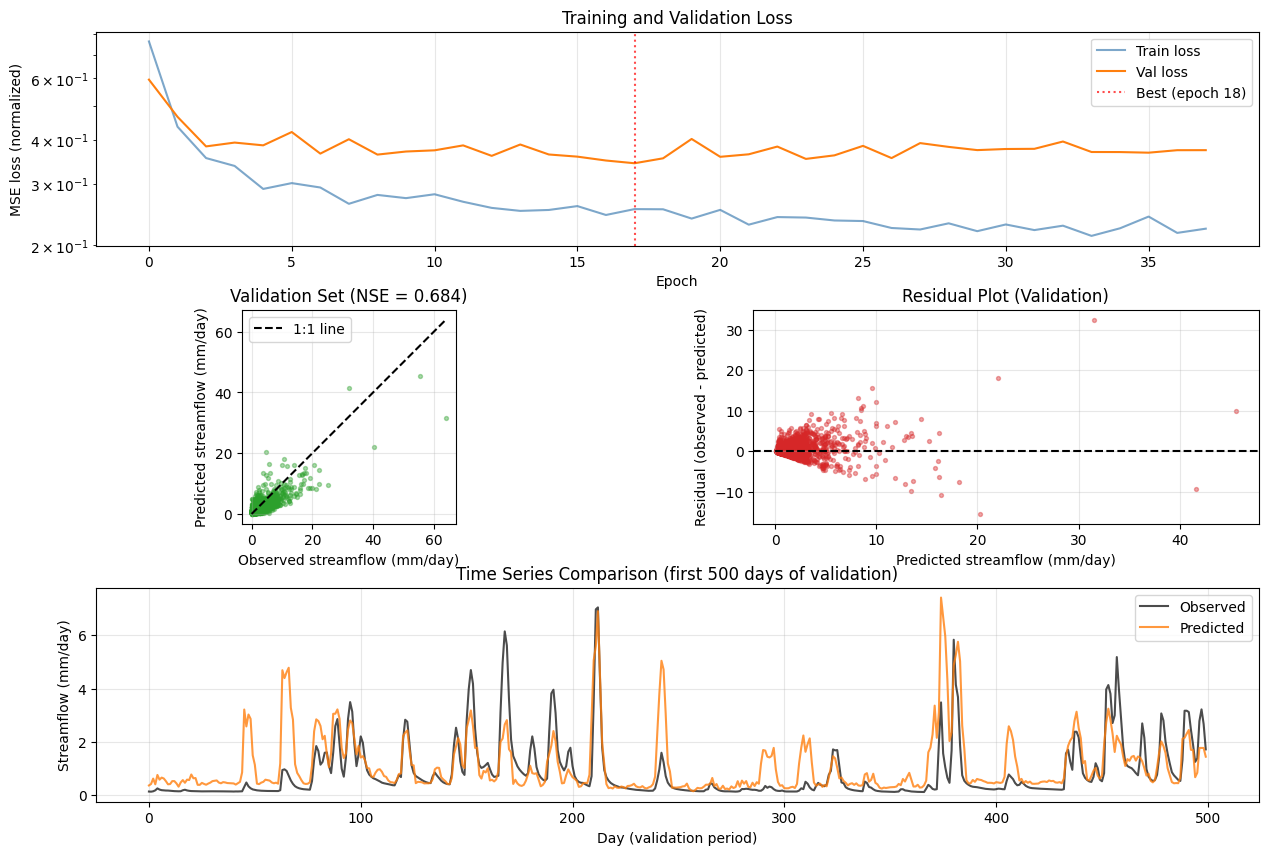

In [19]:
# Plot results
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Loss curves
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_losses, label='Train loss', color='steelblue', linewidth=1.5, alpha=0.7)
ax1.plot(val_losses, label='Val loss', color='C1', linewidth=1.5)
ax1.axvline(best_epoch, color='red', linestyle=':', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE loss (normalized)')
ax1.set_title('Training and Validation Loss')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Scatter: predicted vs observed (validation set)
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_val, y_val_pred, s=8, alpha=0.4, color='C2')
lim = [0, max(y_val.max(), y_val_pred.max())]
ax2.plot(lim, lim, 'k--', linewidth=1.5, label='1:1 line')
ax2.set_xlabel('Observed streamflow (mm/day)')
ax2.set_ylabel('Predicted streamflow (mm/day)')
ax2.set_title(f'Validation Set (NSE = {nse_val:.3f})')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')

# 3. Residuals
ax3 = fig.add_subplot(gs[1, 1])
residuals = y_val - y_val_pred
ax3.scatter(y_val_pred, residuals, s=8, alpha=0.4, color='C3')
ax3.axhline(0, color='k', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Predicted streamflow (mm/day)')
ax3.set_ylabel('Residual (observed - predicted)')
ax3.set_title('Residual Plot (Validation)')
ax3.grid(alpha=0.3)

# 4. Time series comparison (validation period)
ax4 = fig.add_subplot(gs[2, :])
val_days = np.arange(len(y_val))
# Show only first 500 days for clarity
n_show = min(500, len(y_val))
ax4.plot(val_days[:n_show], y_val[:n_show], label='Observed', 
         color='k', linewidth=1.5, alpha=0.7)
ax4.plot(val_days[:n_show], y_val_pred[:n_show], label='Predicted', 
         color='C1', linewidth=1.5, alpha=0.8)
ax4.set_xlabel('Day (validation period)')
ax4.set_ylabel('Streamflow (mm/day)')
ax4.set_title(f'Time Series Comparison (first {n_show} days of validation)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Explore Different Configurations

How does model performance depend on:
- **Lag window** — how many past days to include?
- **Network depth** — how many hidden layers?
- **Network width** — how many neurons per layer?

We run a simple experiment varying the precipitation lag window.

Testing different lag configurations...

Early stopping at epoch 33 (best: epoch 13)
Lag =  3 days — NSE: 0.337, RMSE: 2.437 mm/day
Early stopping at epoch 23 (best: epoch 3)
Lag =  7 days — NSE: 0.639, RMSE: 1.797 mm/day
Early stopping at epoch 29 (best: epoch 9)
Lag = 14 days — NSE: 0.689, RMSE: 1.670 mm/day
Early stopping at epoch 23 (best: epoch 3)
Lag = 21 days — NSE: 0.725, RMSE: 1.571 mm/day
Early stopping at epoch 28 (best: epoch 8)
Lag = 30 days — NSE: 0.793, RMSE: 1.362 mm/day
Early stopping at epoch 33 (best: epoch 13)
Lag = 60 days — NSE: 0.828, RMSE: 1.243 mm/day
Epoch  50 — Train loss: 0.04177, Val loss: 0.18783
Early stopping at epoch 56 (best: epoch 36)
Lag = 90 days — NSE: 0.850, RMSE: 1.162 mm/day


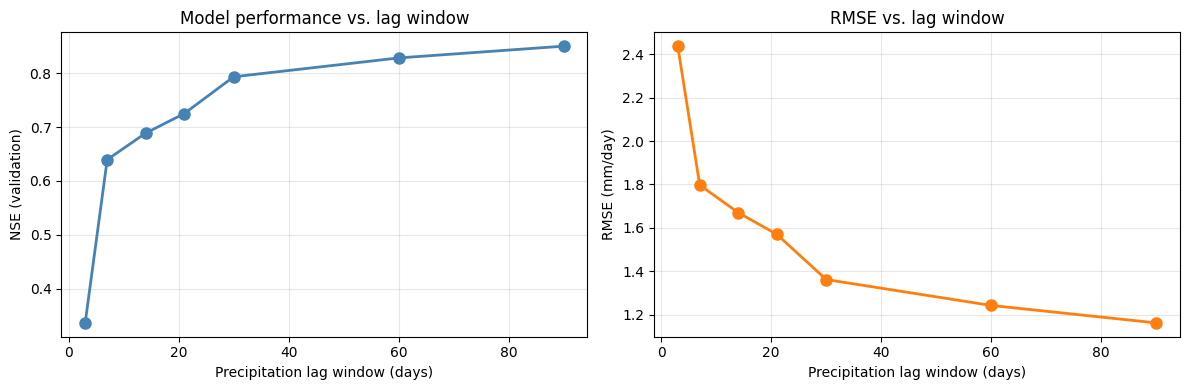

In [56]:
# Experiment: vary precipitation lag window
lag_configs = [3, 7, 14, 21, 30, 60, 90]
results = {}

print("Testing different lag configurations...\n")

all_models = {}
all_val_losses = {}
all_train_losses = {}

for lag_test in lag_configs:
    # Create features
    X_test, y_test = create_lag_features(precip, temp, streamflow, 
                                          lag_p=lag_test, lag_t=lag_test)
    
    # Split
    n_tr = int(0.7 * len(X_test))
    X_tr, X_vl = X_test[:n_tr], X_test[n_tr:]
    y_tr, y_vl = y_test[:n_tr], y_test[n_tr:]
    
    # Normalize
    X_mu, X_sd = X_tr.mean(0), X_tr.std(0) + 1e-8
    y_mu, y_sd = y_tr.mean(), y_tr.std()
    X_tr_norm = (X_tr - X_mu) / X_sd
    X_vl_norm = (X_vl - X_mu) / X_sd
    y_tr_norm = (y_tr - y_mu) / y_sd
    y_vl_norm = (y_vl - y_mu) / y_sd
    
    # Train
    torch.manual_seed(42)
    model_test = StreamflowMLP(n_features=2*lag_test, 
                                hidden_size=48, n_layers=4, dropout_p=0.1)
    train_loss_hist, val_loss_hist, _ = train_model(model_test, X_tr_norm, y_tr_norm, 
                                       X_vl_norm, y_vl_norm,
                                       epochs=200, batch_size=64, 
                                       lr=1e-3, patience=20)
    all_train_losses[lag_test] = train_loss_hist
    all_val_losses[lag_test] = val_loss_hist
    
    # Evaluate
    model_test.eval()
    with torch.no_grad():
        Xv_t = torch.tensor(X_vl_norm, dtype=torch.float32)
        y_pred_norm = model_test(Xv_t).numpy().flatten()
    y_pred = y_pred_norm * y_sd + y_mu
    
    nse_score = nse(y_vl, y_pred)
    rmse = np.sqrt(np.mean((y_vl - y_pred)**2))
    
    results[lag_test] = {'nse': nse_score, 'rmse': rmse, 'val_loss': min(val_loss_hist)}
    print(f"Lag = {lag_test:2d} days — NSE: {nse_score:.3f}, RMSE: {rmse:.3f} mm/day")
    all_models[lag_test] = model_test

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lags = list(results.keys())
nse_vals = [results[l]['nse'] for l in lags]
rmse_vals = [results[l]['rmse'] for l in lags]

axes[0].plot(lags, nse_vals, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Precipitation lag window (days)')
axes[0].set_ylabel('NSE (validation)')
axes[0].set_title('Model performance vs. lag window')
axes[0].grid(alpha=0.3)

axes[1].plot(lags, rmse_vals, 'o-', color='C1', linewidth=2, markersize=8)
axes[1].set_xlabel('Precipitation lag window (days)')
axes[1].set_ylabel('RMSE (mm/day)')
axes[1].set_title('RMSE vs. lag window')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Train MSE Loss')

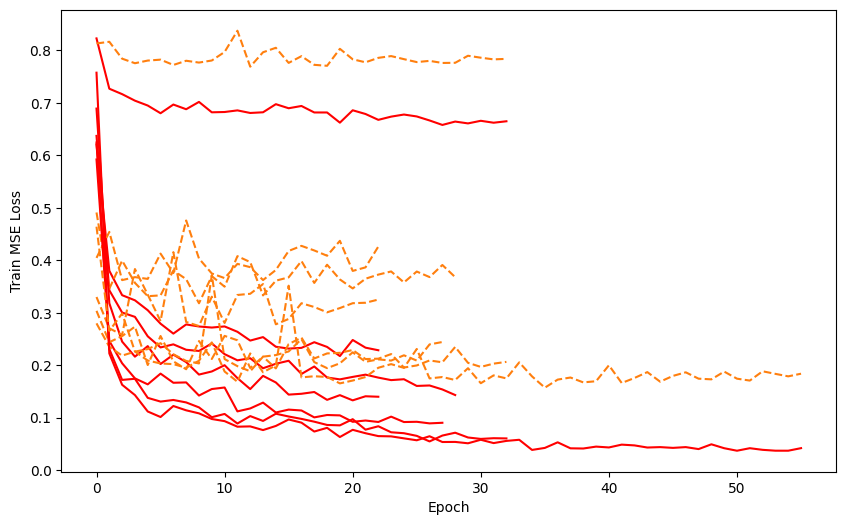

In [57]:
# Make a plot of train losses for each experiment
plt.figure(figsize=(10, 6))
for lag_p_test in lag_configs:
    plt.plot(all_train_losses[lag_p_test], label=f'Lag P={lag_p_test}d', color='red')
    plt.plot(all_val_losses[lag_p_test], label=f'Lag P={lag_p_test}d', color='C1', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Train MSE Loss')


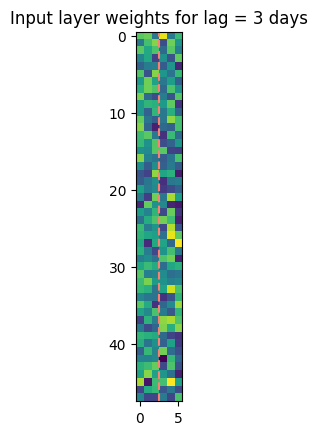

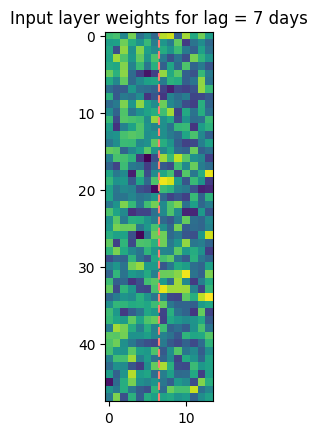

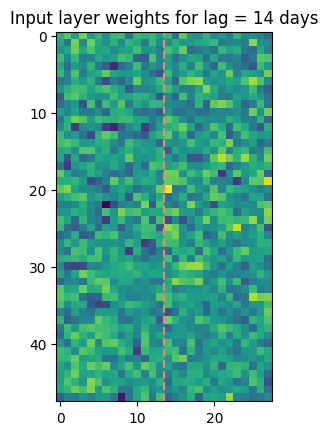

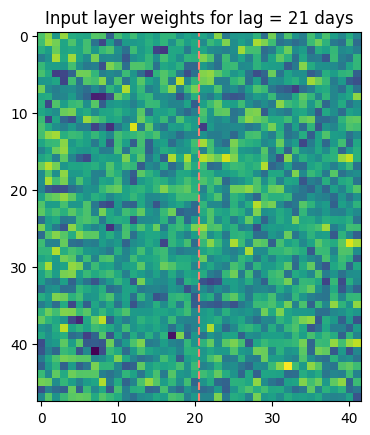

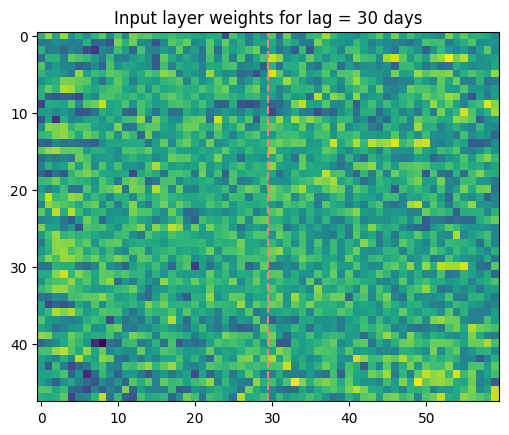

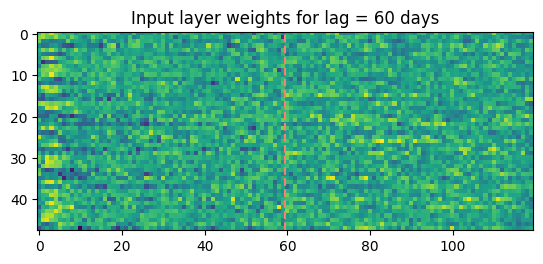

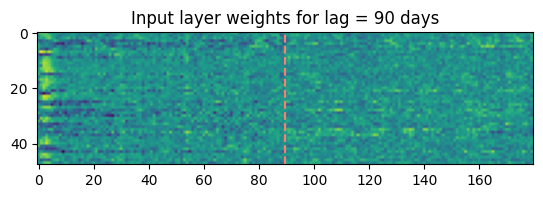

In [59]:
for lag, model_test in all_models.items():
    plt.figure()
    wd = model_test.state_dict()
    all_keys = list(wd.keys())
    plt.imshow(wd[all_keys[0]].numpy())
    plt.axvline(len(wd[all_keys[0]].T)//2-0.5, color='salmon', linestyle='--')
    plt.title(f'Input layer weights for lag = {lag} days')

Performance improves with longer lag windows up to ~14 days, then plateaus. This suggests that streamflow response to precipitation integrates over about 2 weeks — consistent with the basin's hydrological timescale (soil moisture residence time, groundwater recharge).

Beyond 14 days, additional history adds little information and risks overfitting (more parameters, same signal).

## Summary

| Concept | Implementation |
|---|---|
| Time-lag embedding | Stack $L$ past observations into a feature vector |
| Temporal split | Train on past, validate on future — never shuffle time series |
| Normalization | Standardize features using **training statistics only** |
| MLP architecture | Configurable depth, width, dropout via `StreamflowMLP` class |
| Early stopping | Track validation loss, restore best checkpoint |
| Evaluation | NSE (Nash-Sutcliffe Efficiency) — standard metric for hydrology |

### What we learned

- A simple MLP with 7-14 day lag windows achieves NSE ~0.6-0.7 on streamflow prediction
- Performance saturates beyond ~14 days — the basin's memory timescale
- The model captures the overall dynamics but misses some peak flows (extreme events)

### Limitations and next steps

- **Fixed lag window** — LSTMs/GRUs adaptively weight history without manual lag selection
- **No physical constraints** — PINNs/hybrid models can enforce mass balance, energy conservation
- **Single basin** — transfer learning and domain adaptation for ungauged basins

This notebook establishes the baseline supervised learning workflow. Future notebooks will replace the MLP with recurrent architectures and physics-informed losses.